In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns

In [3]:
data = pd.read_csv("D:\knn\Cancer_Data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\k'
<>:1: SyntaxWarning: invalid escape sequence '\k'
C:\Users\abdal\AppData\Local\Temp\ipykernel_31840\3921790617.py:1: SyntaxWarning: invalid escape sequence '\k'
  data = pd.read_csv("D:\knn\Cancer_Data.csv")


In [4]:
data.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
# check for missig values
info_data={
    'isnull':data.isna().sum() ,
    'dublicated' : data.duplicated().sum()
}
info=pd.DataFrame(info_data)
info.T

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
isnull,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,569
dublicated,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data.drop("Unnamed: 32", axis=1, inplace=True)

In [8]:
data.drop("id", axis=1, inplace=True)

In [9]:
# to check all data on diagnosis M and B the unique value must be 2
data['diagnosis'].nunique()

2

In [10]:
data['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [11]:
M = data[data['diagnosis'] == 'M']
B = data[data['diagnosis'] == 'B']

In [12]:
# we want to choose features to make scatter plot
# our features x and y must make diffrence between B , M

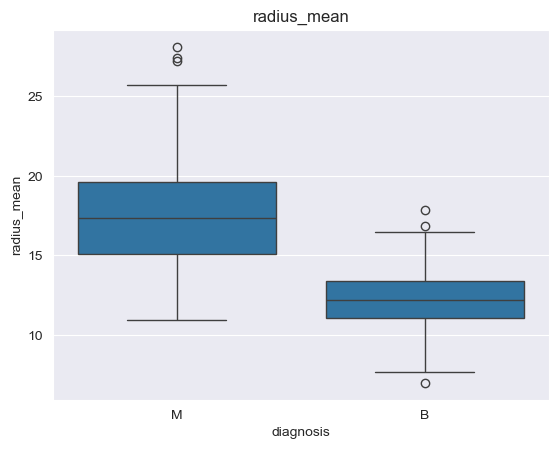

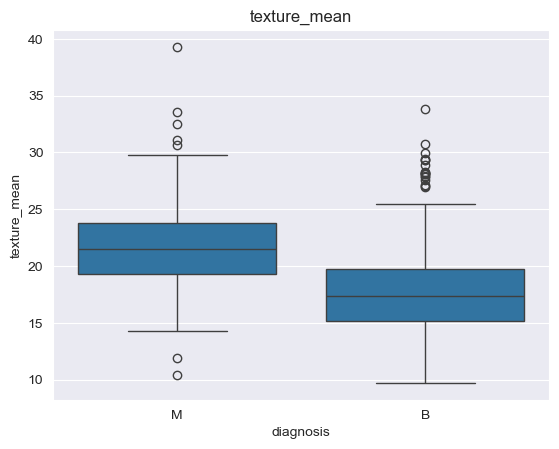

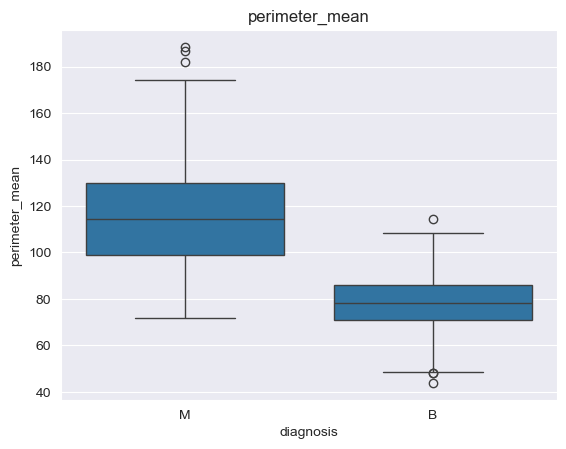

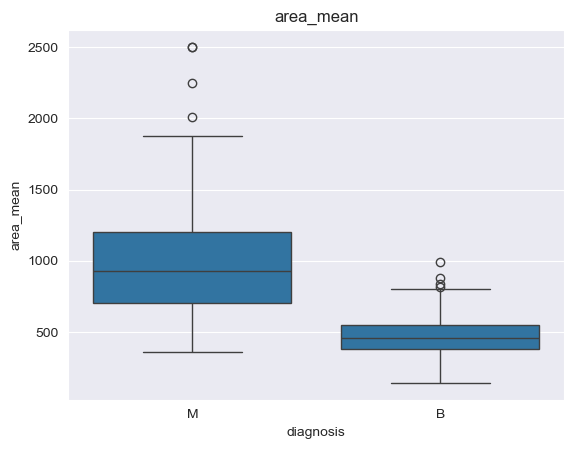

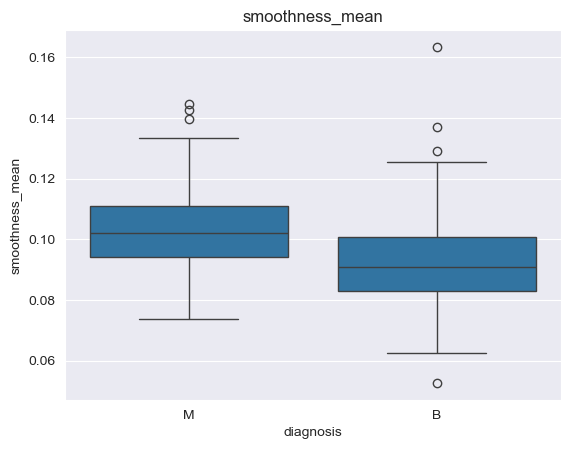

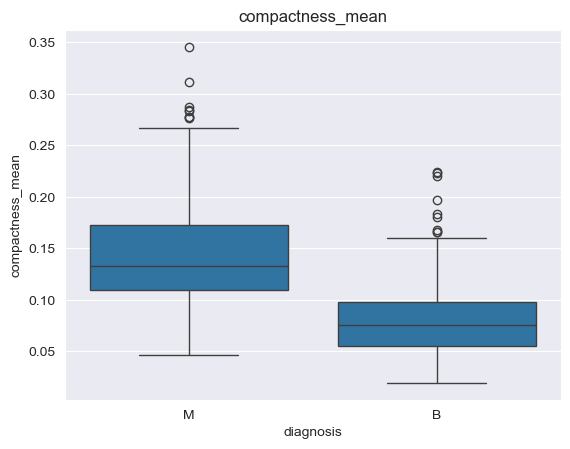

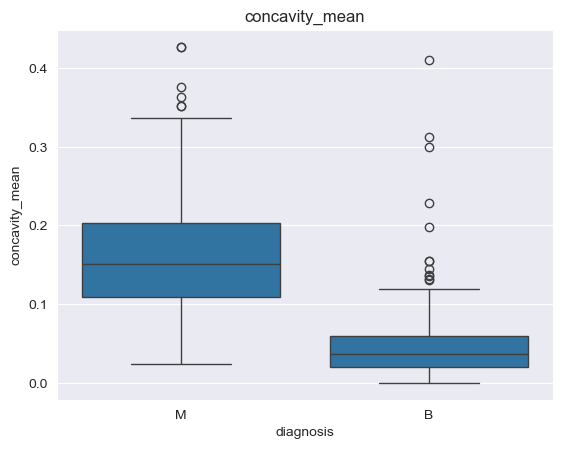

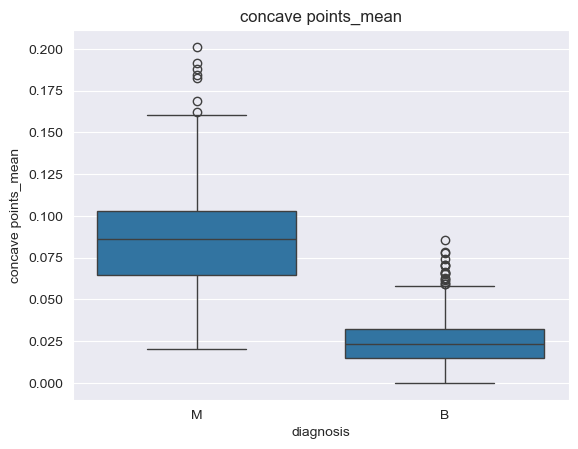

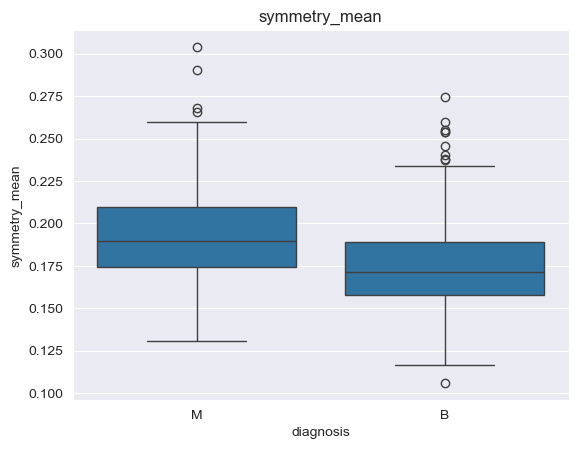

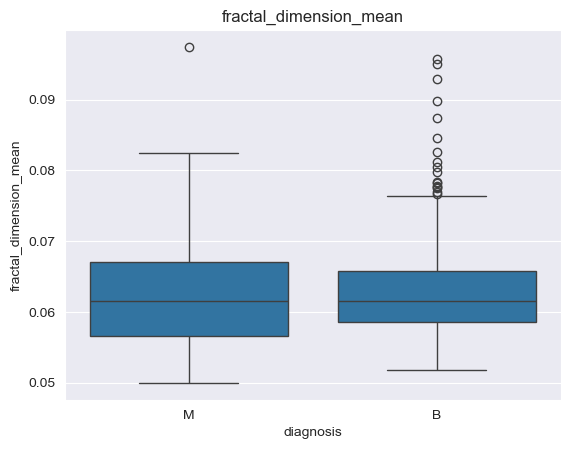

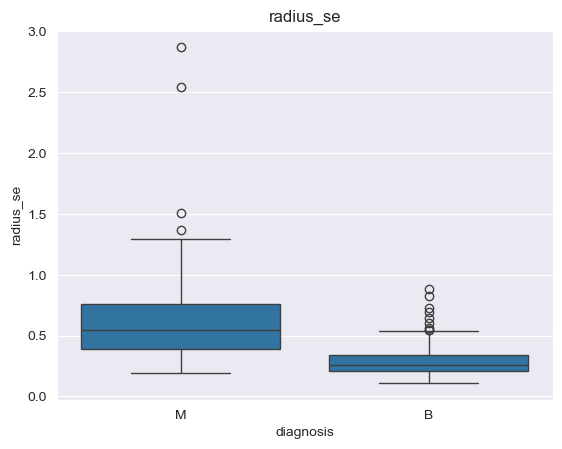

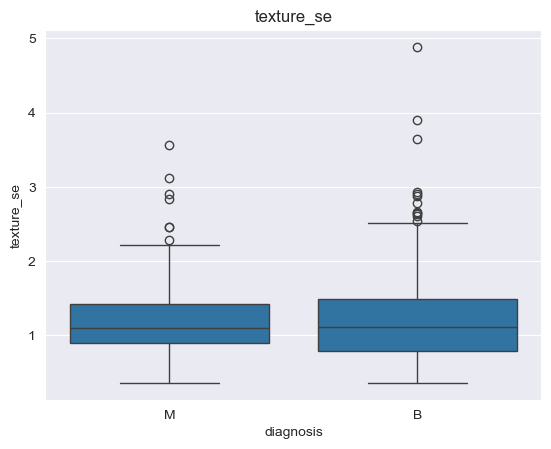

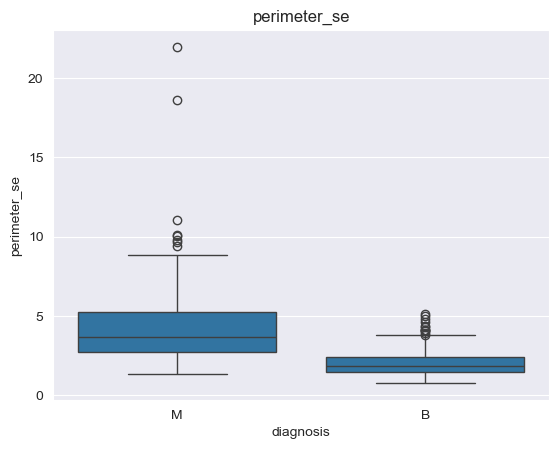

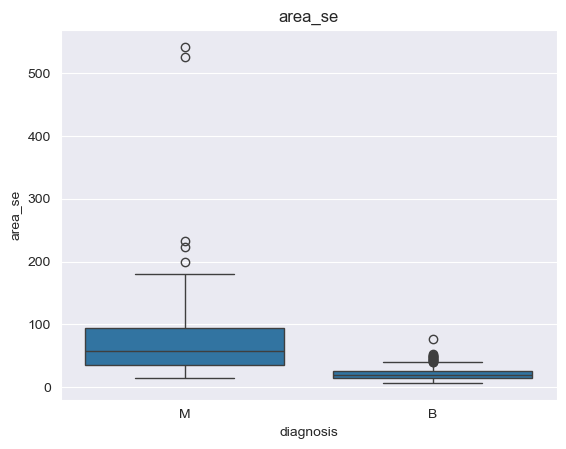

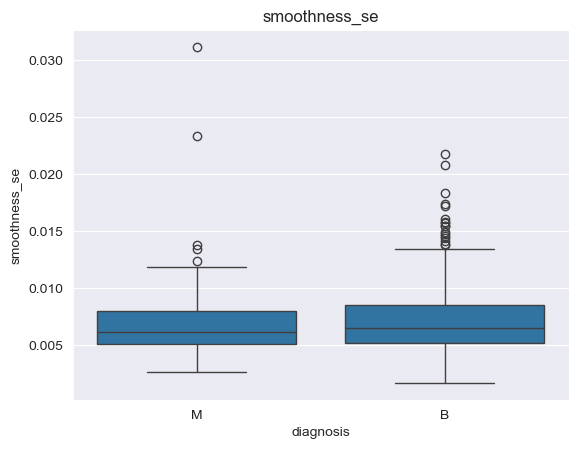

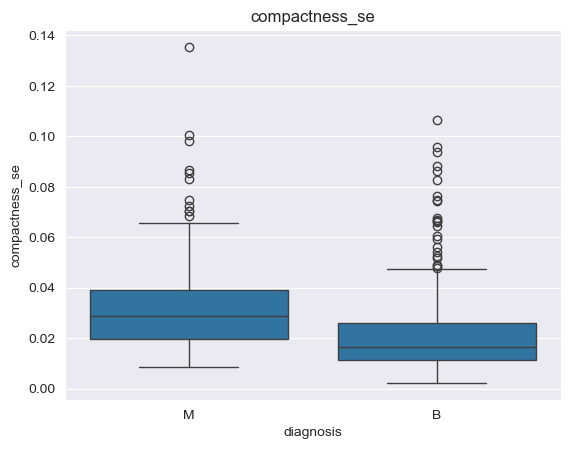

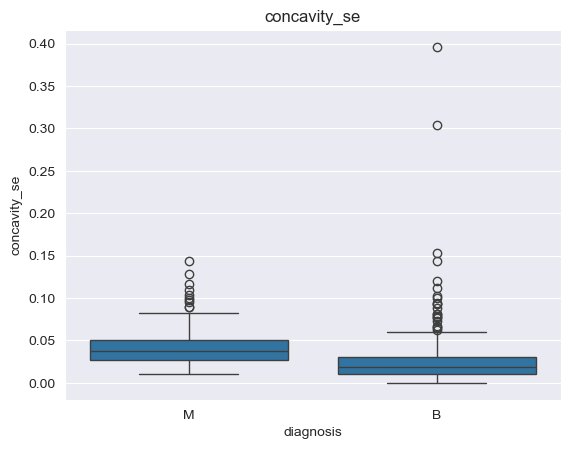

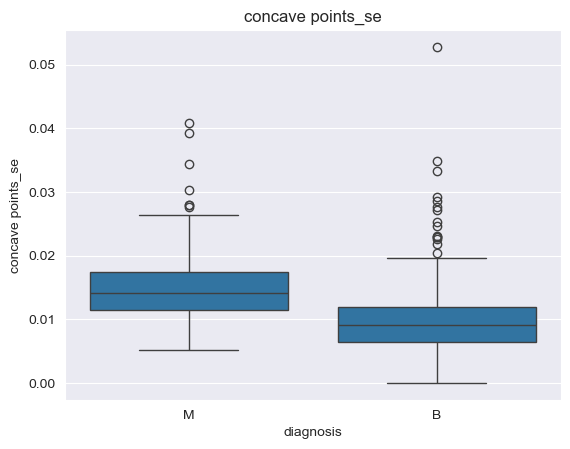

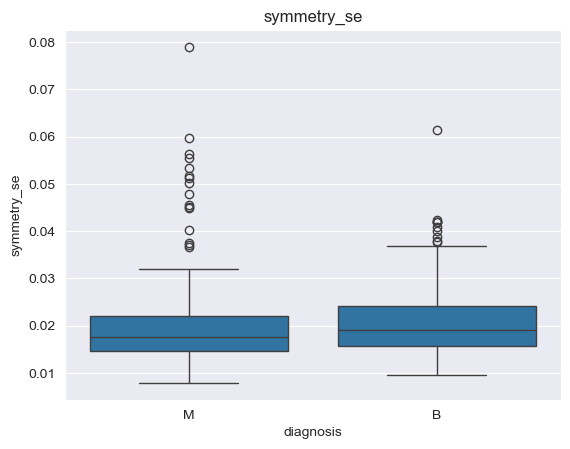

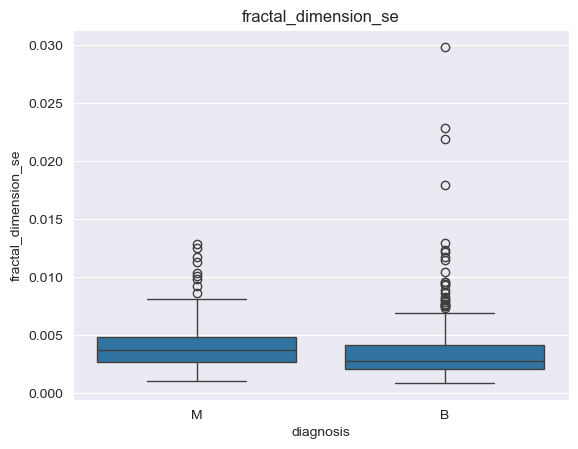

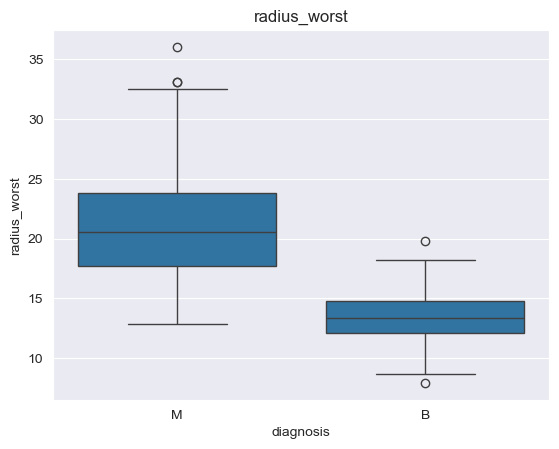

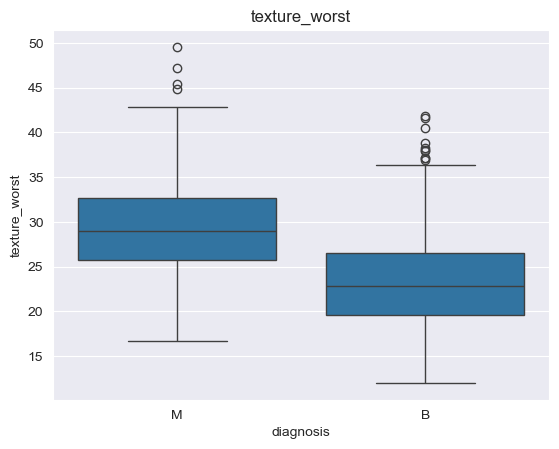

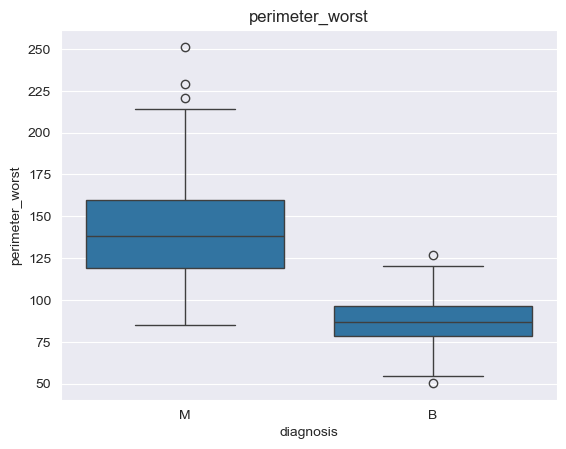

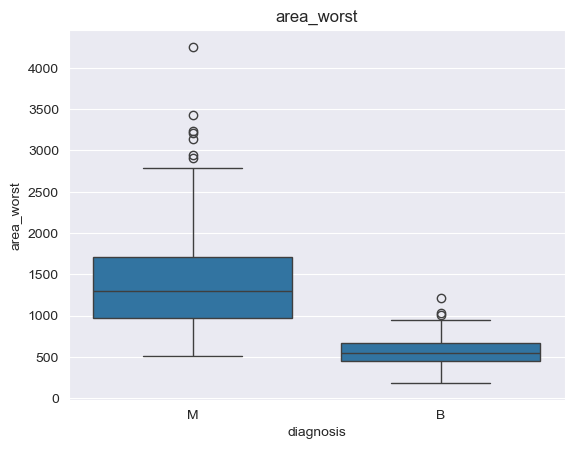

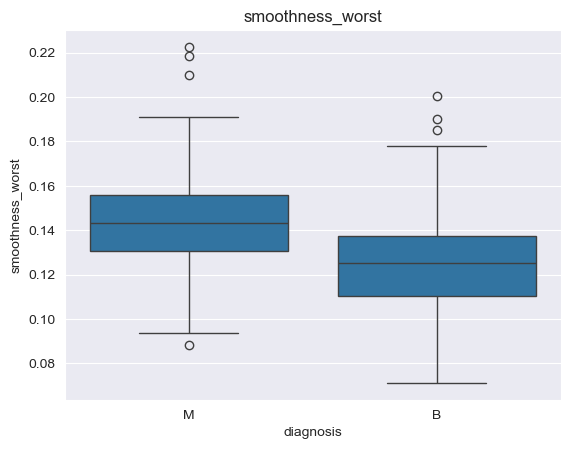

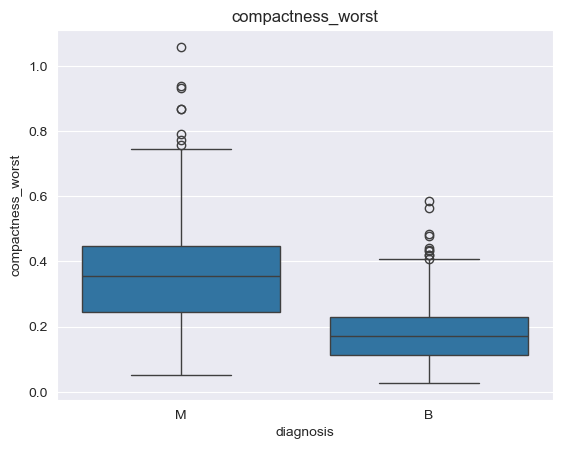

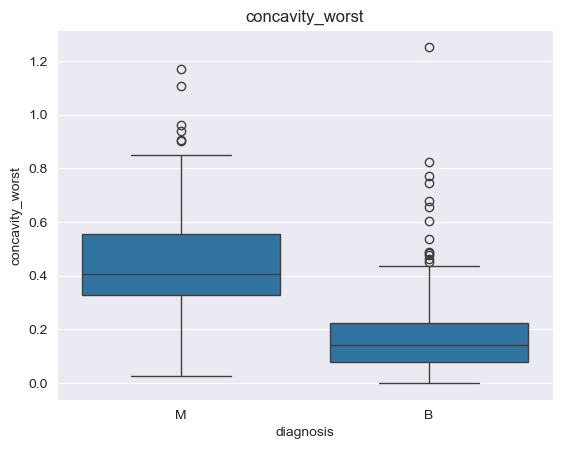

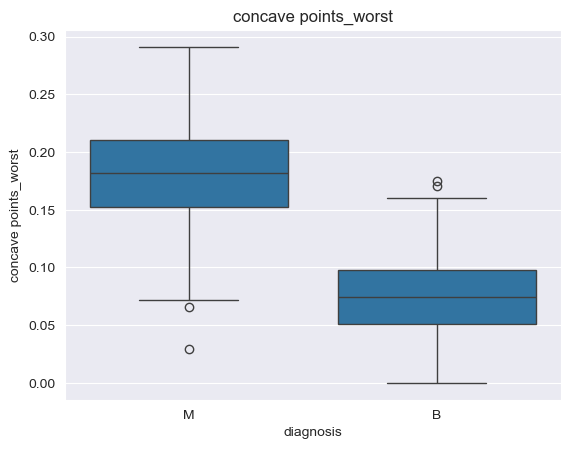

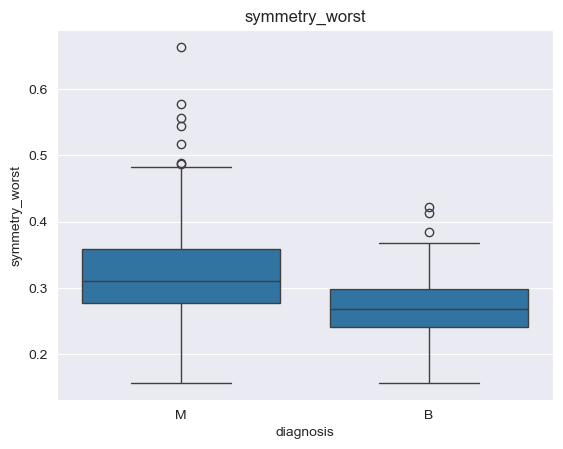

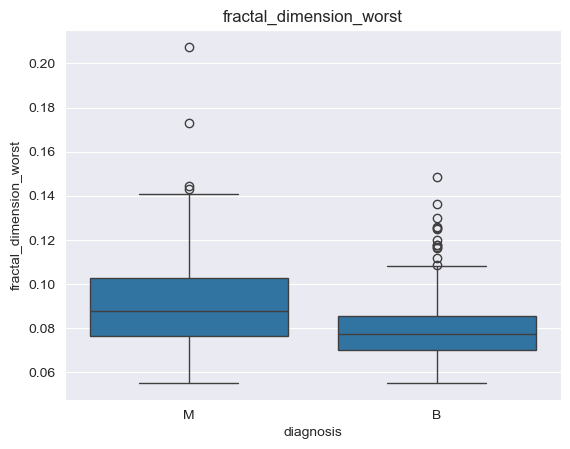

In [13]:
features = data.columns[1:]

for col in features:

    sns.boxplot(
        x='diagnosis',
        y=col,
        data=data
    )

    plt.title(col)
    plt.show()

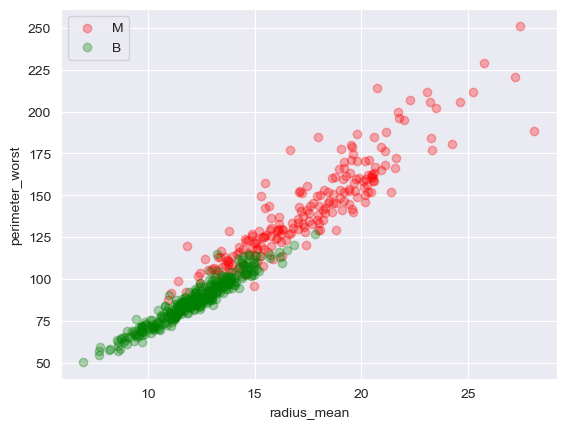

In [14]:
# scatter_plot
plt.scatter(M.radius_mean,M.perimeter_worst,color="red",label="M",alpha=.3)
plt.scatter(B.radius_mean,B.perimeter_worst,color="green",label="B",alpha=.3)

plt.xlabel("radius_mean")
plt.ylabel("perimeter_worst")

plt.legend()
plt.show()

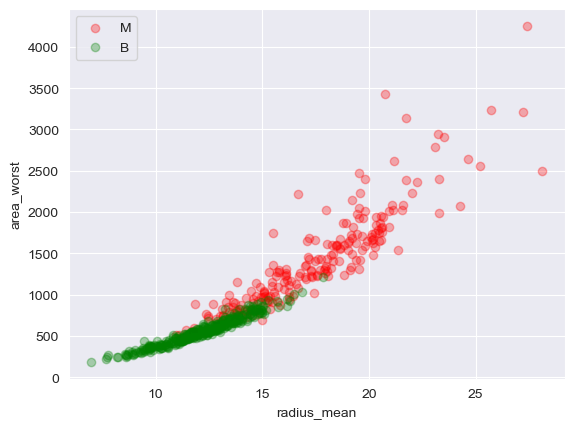

In [15]:
# we have obvious overlap so we will change the y feature
plt.scatter(M.radius_mean,M.area_worst,color="red",label="M",alpha=.3)
plt.scatter(B.radius_mean,B.area_worst,color="green",label="B",alpha=.3)

plt.xlabel("radius_mean")
plt.ylabel("area_worst")

plt.legend()
plt.show()

In [16]:
data = data.rename(
    columns={
        'concave points_worst': 'concave_points_worst'
    }
)

In [17]:
M = data[data['diagnosis'] == 'M']
B = data[data['diagnosis'] == 'B']

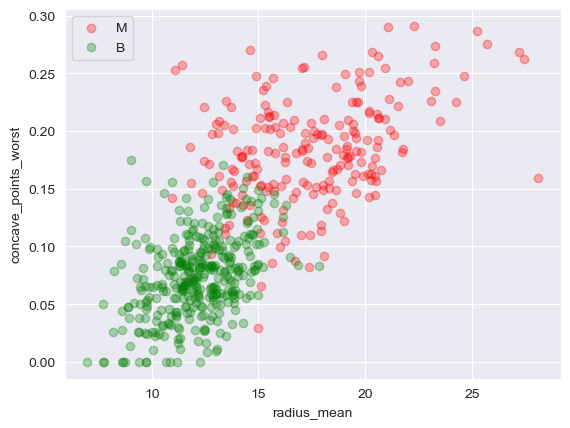

In [18]:
# we have obvious overlap so we will change the y feature
plt.scatter(M.radius_mean,M.concave_points_worst,color="red",label="M",alpha=.3)
plt.scatter(B.radius_mean,B.concave_points_worst,color="green",label="B",alpha=.3)

plt.xlabel("radius_mean")
plt.ylabel("concave_points_worst")

plt.legend()
plt.show()

In [19]:
# We can go on with that

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [21]:
data['diagnosis'] = data['diagnosis'].map({
    'M':1,
    'B':0
})

In [22]:
#choose features connected not weak and unsimilar
#Correlation
data.corr(numeric_only=True)['diagnosis']

diagnosis                  1.000000
radius_mean                0.730029
texture_mean               0.415185
perimeter_mean             0.742636
area_mean                  0.708984
smoothness_mean            0.358560
compactness_mean           0.596534
concavity_mean             0.696360
concave points_mean        0.776614
symmetry_mean              0.330499
fractal_dimension_mean    -0.012838
radius_se                  0.567134
texture_se                -0.008303
perimeter_se               0.556141
area_se                    0.548236
smoothness_se             -0.067016
compactness_se             0.292999
concavity_se               0.253730
concave points_se          0.408042
symmetry_se               -0.006522
fractal_dimension_se       0.077972
radius_worst               0.776454
texture_worst              0.456903
perimeter_worst            0.782914
area_worst                 0.733825
smoothness_worst           0.421465
compactness_worst          0.590998
concavity_worst            0

In [23]:
data.corr(numeric_only=True)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


In [24]:
X = data[
    [
        'radius_mean',
        'texture_mean',
        'perimeter_worst',
        'concave_points_worst',
        'area_worst'
    ]
]

In [25]:
Y = data['diagnosis']

In [37]:
y=Y.map({
    'M':1,
    'B':0
})


In [38]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.2,random_state=42)


In [39]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [40]:
model= KNeighborsClassifier(n_neighbors=7)
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [41]:
y_pred=model.predict(x_test)

In [42]:
print(f"the model accuracy is {accuracy_score(y_test, y_pred)}")

the model accuracy is 0.9736842105263158


In [43]:
print(" x test and y test \n")
x_test , y_test

 x test and y test 



(array([[-0.46649743, -0.13728933, -0.33154752, -0.19435087, -0.35109337],
        [ 1.36536344,  0.49866473,  1.76366112,  0.99177862,  1.7441412 ],
        [ 0.38006578,  0.06921974,  0.53383214,  0.57035018,  0.49204412],
        [-0.48631664, -0.35318518, -0.52472066, -0.62037671, -0.63695948],
        [-0.72980974, -1.11351403, -0.84957549, -0.68964422, -0.73924347],
        [ 1.83536175,  2.38071331,  2.32458312,  2.31123274,  1.66478293],
        [ 2.23457718,  0.63711968,  2.63653974,  1.97715492,  2.38077084],
        [ 0.97747327, -0.9703657 ,  0.83379043,  0.48146709,  0.61725382],
        [-0.22017302, -0.78028349, -0.31325007,  0.86764879, -0.46219494],
        [-0.06161937, -0.60193474, -0.177069  , -0.79630392, -0.27878917],
        [-0.25698012,  1.42326216, -0.47432767, -0.82955846, -0.43045164],
        [ 0.75379938, -0.09035545,  0.70780795,  0.5090515 ,  0.67544989],
        [ 0.24133134,  0.13492717, -0.14407359, -0.86802338, -0.1673349 ],
        [ 0.60657099,  0.

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)


    disp = ConfusionMatrixDisplay(confusion_matrix=cm)


    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(cmap='Blues', ax=ax, values_format='d')

    plt.title("Confusion Matrix (Binary / One-Class)")
    plt.show()

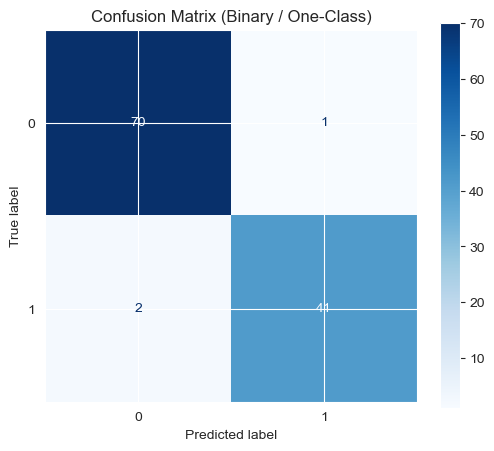

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
plot_confusion_matrix(y_test, y_pred)